In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# ==========================================
# 1. IMPORTAR EL DATASET
# ==========================================

# Usamos sep=';' porque es el delimitador del archivo
df = pd.read_csv('dataset_elpino.csv', sep=';', low_memory=False)

In [ ]:
# ==========================================
# 2. LIMPIEZA DE "NULOS OCULTOS"
# ==========================================
# El dataset usa "-" para indicar que no hay dato.
# Pandas no entiende eso, así que lo cambiamos por el nulo matemático (NaN)
df.replace('-', np.nan, inplace=True)

In [ ]:
# ==========================================
# 3. EXTRACCIÓN DE CÓDIGOS (Feature Engineering)
# ==========================================
print("Limpiando textos de diagnósticos y procedimientos...")

# Identificamos automáticamente qué columnas son de Diagnóstico y cuáles de Procedimiento
cols_diag = [col for col in df.columns if col.startswith('Diag')]
cols_proc = [col for col in df.columns if col.startswith('Proced')]

# Función para cortar el texto y quedarnos SOLO con el código (lo que está antes del ' - ')
def extraer_codigo(texto):
    if pd.isna(texto):
        return np.nan
    # Corta el texto en el guion y se queda con la primera parte [0]
    return str(texto).split(' - ')[0].strip()

# Aplicamos la función a todas las columnas de diagnósticos y procedimientos
for col in cols_diag + cols_proc:
    df[col] = df[col].apply(extraer_codigo)

Limpiando textos de diagnósticos y procedimientos...


In [ ]:
# ==========================================
# 4. CREACIÓN DE NUEVAS VARIABLES (Feature Engineering)
# ==========================================
print("Creando variables de conteo...")
# A los algoritmos les sirve mucho saber la "cantidad" total de enfermedades o intervenciones
# Aquí contamos cuántos valores NO nulos tiene cada paciente en sus listas
df['Total_Diagnosticos'] = df[cols_diag].notna().sum(axis=1)
df['Total_Procedimientos'] = df[cols_proc].notna().sum(axis=1)

Creando variables de conteo...


In [ ]:
# ==========================================
# 5. CODIFICAR VARIABLES CATEGÓRICAS (Sexo)
# ==========================================
# Pasamos el texto a números binarios para que el algoritmo lo entienda
df['Sexo_Codificado'] = df['Sexo (Desc)'].map({'Hombre': 0, 'Mujer': 1})
# Si por casualidad hay algún otro valor (como 'Indeterminado'), lo dejamos como -1 temporalmente
df['Sexo_Codificado'] = df['Sexo_Codificado'].fillna(-1)

In [ ]:
# ==========================================
# 6. LIMPIAR LA VARIABLE OBJETIVO (TARGET: GRD)
# ==========================================
# Hacemos lo mismo: extraemos solo el código del GRD
df['GRD_Target'] = df['GRD'].apply(extraer_codigo)

In [ ]:
# ==========================================
# 7. VISTAZO AL RESULTADO
# ==========================================
print("\n¡Limpieza completada! Vistazo a las variables clave:")
# Mostramos las variables numéricas y limpias que acabamos de generar
columnas_resumen = ['Edad en años', 'Sexo_Codificado', 'Total_Diagnosticos', 'Total_Procedimientos', 'GRD_Target']
display(df[columnas_resumen].head())


¡Limpieza completada! Vistazo a las variables clave:


,Edad en años,Sexo_Codificado,Total_Diagnosticos,Total_Procedimientos,GRD_Target
0,40,0,28,30,184103
1,53,0,17,30,041013
2,65,0,32,30,041013
3,61,0,19,30,041023
4,30,0,22,30,041023


In [ ]:
# ==========================================
# MULTI-HOT ENCODING
# ==========================================
from sklearn.preprocessing import MultiLabelBinarizer

# --- Top 100 diagnósticos más frecuentes ---
# Aumentamos de 50 a 100 para dar más vocabulario al modelo
# Tu profe mostró que X ∈ {0,1}^D — un D más grande captura más información
todos_diag = pd.Series(df[cols_diag].values.flatten()).dropna()
top100_diag = todos_diag.value_counts().head(100).index.tolist()

# --- Top 50 procedimientos más frecuentes ---
todos_proc = pd.Series(df[cols_proc].values.flatten()).dropna()
top50_proc = todos_proc.value_counts().head(50).index.tolist()

# --- Función para convertir fila a lista de códigos presentes ---
def fila_a_lista(row, top_codigos):
    return [c for c in row.dropna().values if c in top_codigos]

# --- Aplicar a cada paciente ---
diag_listas = df[cols_diag].apply(lambda row: fila_a_lista(row, top100_diag), axis=1)
proc_listas = df[cols_proc].apply(lambda row: fila_a_lista(row, top50_proc), axis=1)

# --- Binarizar ---
mlb_diag = MultiLabelBinarizer(classes=top100_diag)
mlb_proc = MultiLabelBinarizer(classes=top50_proc)

diag_encoded = pd.DataFrame(mlb_diag.fit_transform(diag_listas),
                             columns=['DIAG_' + c for c in top100_diag],
                             index=df.index)

proc_encoded = pd.DataFrame(mlb_proc.fit_transform(proc_listas),
                             columns=['PROC_' + c for c in top50_proc],
                             index=df.index)

# --- Armar features finales ---
features_numericas = df[['Edad en años', 'Sexo_Codificado',
                          'Total_Diagnosticos', 'Total_Procedimientos']].copy()

X = pd.concat([features_numericas, diag_encoded, proc_encoded], axis=1)
y = df['GRD_Target']

print(f"✅ Shape de X: {X.shape}")
print(f"✅ Clases únicas en y: {y.nunique()}")

✅ Shape de X: (14561, 154)
✅ Clases únicas en y: 526


In [ ]:
# ==========================================
# DIVISIÓN 80/20 CON STRATIFY
# ==========================================
from sklearn.model_selection import train_test_split

# Filtramos clases con menos de 5 muestras totales
# Regla de tu profe: 10 datos por parámetro (semana 2)
# Con menos de 5 muestras es imposible aprender un patrón
# y el modelo simplemente memoriza sin generalizar
conteo = y.value_counts()
clases_validas = conteo[conteo >= 5].index
mask = y.isin(clases_validas)

X_filtrado = X[mask]
y_filtrado = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_filtrado, y_filtrado,
    test_size=0.2,
    random_state=42,
    stratify=y_filtrado
)

print(f"✅ Clases eliminadas por tener < 5 muestras: {y.nunique() - y_filtrado.nunique()}")
print(f"✅ Clases que quedan: {y_filtrado.nunique()}")
print(f"✅ Train: {X_train.shape[0]} filas")
print(f"✅ Test : {X_test.shape[0]} filas")
print(f"✅ Clases en train: {y_train.nunique()} | en test: {y_test.nunique()}")

✅ Clases eliminadas por tener < 5 muestras: 199
✅ Clases que quedan: 327
✅ Train: 11308 filas
✅ Test : 2827 filas
✅ Clases en train: 327 | en test: 327


In [ ]:
# ==========================================
# ENTRENAMIENTO DE MODELOS
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import time

# --- Random Forest ---
# n_estimators=300: más árboles reduce la varianza (como promediar más modelos)
# Tu profe mostró en semana 2 que el sobreajuste (M=9) ocurre cuando el modelo
# se ajusta demasiado a los datos de entrenamiento. Promediar 300 árboles
# independientes reduce ese efecto.
#
# min_samples_leaf=2: equivale a la regularización λ/2||w||² que mostró tu profe.
# Impide que el árbol cree ramas para un solo paciente, forzando generalización.
#
# class_weight='balanced': compensa el desbalance de clases.
# Sin esto el modelo optimiza accuracy ignorando GRDs raros,
# lo que destruye el Macro F1.

print("Entrenando Random Forest...")
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print(f"✅ RF entrenado en {time.time()-t0:.1f}s")

# --- XGBoost ---
# n_estimators=300: igual que RF, más iteraciones mejoran el modelo
# max_depth=6: controla la complejidad de cada árbol (como el M del polinomio
# que mostró tu profe — muy profundo = sobreajuste, muy poco = subajuste)
# learning_rate=0.1: cada árbol corrige los errores del anterior con pasos
# pequeños, más estable que pasos grandes

print("\nEntrenando XGBoost...")
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

t0 = time.time()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train_enc)
print(f"✅ XGBoost entrenado en {time.time()-t0:.1f}s")

Entrenando Random Forest...
✅ RF entrenado en 12.2s

Entrenando XGBoost...
✅ XGBoost entrenado en 459.8s


In [ ]:
# ==========================================
# CELDA 4: EVALUACIÓN
# ==========================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --- Predicciones ---
y_pred_rf  = rf.predict(X_test)
y_pred_xgb = le.inverse_transform(xgb.predict(X_test))

# --- Classification Report ---
print("=" * 55)
print("RANDOM FOREST — Classification Report")
print("=" * 55)
rf_report = classification_report(y_test, y_pred_rf, zero_division=0, output_dict=True)
print(classification_report(y_test, y_pred_rf, zero_division=0))
print(f"🎯 Macro F1 RF  : {rf_report['macro avg']['f1-score']:.4f}")

print("\n" + "=" * 55)
print("XGBOOST — Classification Report")
print("=" * 55)
xgb_report = classification_report(y_test, y_pred_xgb, zero_division=0, output_dict=True)
print(classification_report(y_test, y_pred_xgb, zero_division=0))
print(f"🎯 Macro F1 XGB : {xgb_report['macro avg']['f1-score']:.4f}")

# --- Matriz de confusión (Top 10 clases más frecuentes en test) ---
top10_clases = y_test.value_counts().head(10).index.tolist()
mask_top10   = y_test.isin(top10_clases)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (y_pred, nombre) in zip(axes, [(y_pred_rf, 'Random Forest'),
                                        (y_pred_xgb, 'XGBoost')]):
    ConfusionMatrixDisplay.from_predictions(
        y_test[mask_top10],
        np.array(y_pred)[mask_top10],
        labels=top10_clases,
        ax=ax,
        colorbar=False,
        xticks_rotation=45
    )
    ax.set_title(f'Matriz de Confusión — {nombre}\n(Top 10 GRD más frecuentes)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluación completada.")

NameError: name 'rf' is not defined

Calculando SHAP para Random Forest (puede tardar)...

📊 Explicación Global — Random Forest


/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_29843/3716139245.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


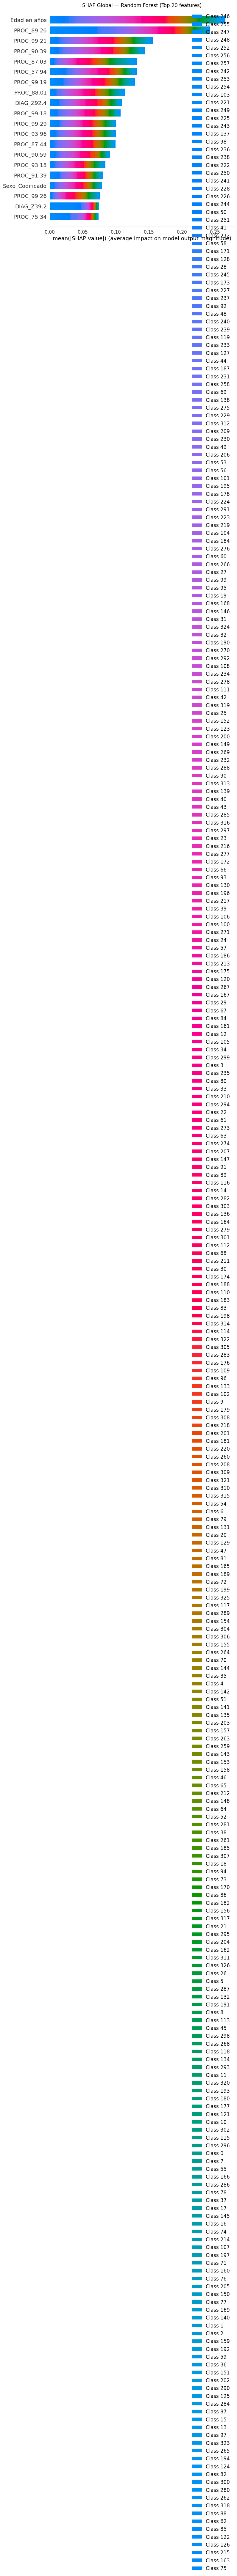


Calculando SHAP para XGBoost...


In [ ]:
# ==========================================
#  SHAP — EXPLICABILIDAD
# ==========================================
import shap
import matplotlib.pyplot as plt

print("Calculando SHAP para Random Forest (puede tardar)...")
explainer_rf = shap.TreeExplainer(rf)

X_sample = X_test.sample(n=min(200, len(X_test)), random_state=42)
shap_values_rf = explainer_rf.shap_values(X_sample)

print("\n📊 Explicación Global — Random Forest")
shap.summary_plot(
    shap_values_rf,
    X_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("SHAP Global — Random Forest (Top 20 features)")
plt.tight_layout()
plt.savefig('shap_global_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCalculando SHAP para XGBoost...")
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_sample)

print("\n📊 Explicación Global — XGBoost")
shap.summary_plot(
    shap_values_xgb,
    X_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title("SHAP Global — XGBoost (Top 20 features)")
plt.tight_layout()
plt.savefig('shap_global_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

idx = 0
clase_predicha_rf = rf.predict(X_sample.iloc[[idx]])[0]
print(f"\n🔍 Explicación Local — paciente index {X_sample.index[idx]}")
print(f"   GRD predicho por RF: {clase_predicha_rf}")

clases_rf = rf.classes_.tolist()
if clase_predicha_rf in clases_rf:
    idx_clase = clases_rf.index(clase_predicha_rf)
    shap.plots._waterfall.waterfall_legacy(
        explainer_rf.expected_value[idx_clase],
        shap_values_rf[idx_clase][idx],
        feature_names=X_sample.columns.tolist(),
        max_display=15,
        show=False
    )
    plt.title(f"SHAP Local RF — GRD: {clase_predicha_rf}")
    plt.tight_layout()
    plt.savefig('shap_local_rf.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ SHAP completado.")

In [ ]:
#Entrenamiento Solo XGBoost:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import time

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Entrenando XGBoost...")
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train_enc)
print(f"✅ XGBoost listo en {time.time()-t0:.1f}s")

Entrenando XGBoost...
✅ XGBoost listo en 470.2s


/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_85322/2764271600.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


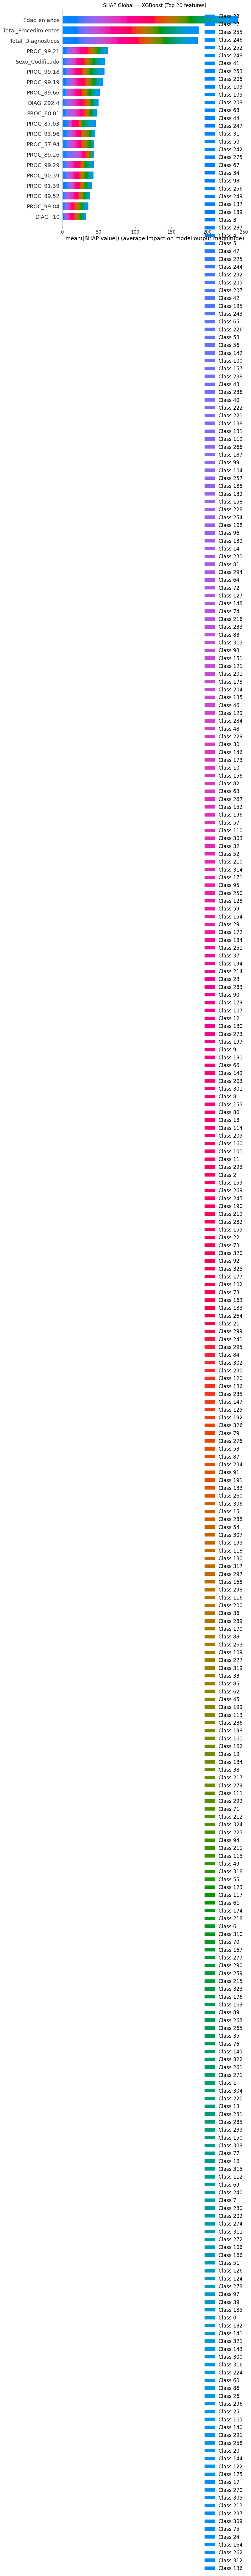

✅ Listo.


In [ ]:
# ==========================================
# SHAP — SOLO XGBoost (menos RAM)
# ==========================================
import shap
import matplotlib.pyplot as plt

explainer_xgb = shap.TreeExplainer(xgb)
X_sample = X_test.sample(n=100, random_state=42)
shap_values_xgb = explainer_xgb.shap_values(X_sample)

shap.summary_plot(shap_values_xgb, X_sample, plot_type='bar', max_display=20, show=False)
plt.title("SHAP Global — XGBoost (Top 20 features)")
plt.tight_layout()
plt.savefig('shap_global_xgb.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Listo.")